**Clasificación de variedades de trigo con Python**

Álgebra lineal, estadística y modelos de Machine Learning (PIAD-426)

Nota: `seeds_dataset.csv` es un dataset sintético con la estructura del dataset Seeds.

Importaciones y carga

In [58]:
import numpy as np

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

df = pd.read_csv("seeds_dataset.csv")
df.head()

,Area,Perimeter,Compactness,Length_of_kernel,Width_of_kernel,Asymmetry_coefficient,Length_of_kernel_groove,Class
0,14.472,14.450,0.877,5.753,3.324,1.356,4.870,Kama
1,11.574,12.751,0.853,5.158,2.773,3.502,5.139,Canadian
2,15.100,14.586,0.878,5.711,3.355,2.122,5.092,Kama
3,11.862,13.277,0.809,5.302,3.007,4.345,5.097,Canadian
4,15.707,14.932,0.863,5.695,3.337,2.724,5.256,Kama


Exploración

In [59]:
print("Forma:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)
print("\nNulos por columna:")
print(df.isnull().sum())
print("\nDuplicados:", df.duplicated().sum())
print("\nDistribución de la variable objetivo:")
print(df["Class"].value_counts())
df.describe().round(3)

Forma: (210, 8)

Tipos de datos:
Area                       float64
Perimeter                  float64
Compactness                float64
Length_of_kernel           float64
Width_of_kernel            float64
Asymmetry_coefficient      float64
Length_of_kernel_groove    float64
Class                          str
dtype: object

Nulos por columna:
Area                       0
Perimeter                  0
Compactness                0
Length_of_kernel           0
Width_of_kernel            0
Asymmetry_coefficient      0
Length_of_kernel_groove    0
Class                      0
dtype: int64

Duplicados: 0

Distribución de la variable objetivo:
Class
Kama        70
Canadian    70
Rosa        70
Name: count, dtype: int64


,Area,Perimeter,Compactness,Length_of_kernel,Width_of_kernel,Asymmetry_coefficient,Length_of_kernel_groove
count,210.000,210.000,210.000,210.000,210.000,210.000,210.000
mean,14.757,14.515,0.871,5.614,3.244,3.618,5.400
std,2.822,1.281,0.024,0.427,0.381,1.329,0.484
min,10.105,12.235,0.779,4.846,2.389,0.230,4.636
25%,12.143,13.370,0.858,5.267,2.917,2.716,5.044
50%,14.479,14.369,0.873,5.498,3.266,3.726,5.208
75%,17.101,15.606,0.887,5.914,3.543,4.559,5.864
max,21.206,17.634,0.923,6.727,4.041,6.815,6.558


Preparación

In [60]:
X = df.drop(columns="Class")
y = df["Class"]
caracteristicas = X.columns.tolist()
print(caracteristicas)
print("X:", X.shape, "| y:", y.shape)

['Area', 'Perimeter', 'Compactness', 'Length_of_kernel', 'Width_of_kernel', 'Asymmetry_coefficient', 'Length_of_kernel_groove']
X: (210, 7) | y: (210,)


Normalización con StandardScaler

In [61]:
#Se normaliza todo X antes de separar, siguiendo la pauta de clase (AS_001 y AS_002).
escalador = StandardScaler()
X_esc = escalador.fit_transform(X)

print("Media por característica:", X_esc.mean(axis=0).round(3))
print("Desviación por característica:", X_esc.std(axis=0).round(3))

Media por característica: [-0.  0. -0.  0. -0.  0. -0.]
Desviación por característica: [1. 1. 1. 1. 1. 1. 1.]


**Nota metodológica:** en este trabajo se escala todo X antes de dividir, como indica el enunciado y la pauta de clase. En un proyecto real conviene dividir primero y ajustar el escalador solo con el entrenamiento, para que el conjunto de prueba no influya en la media y la desviación (fuga de datos).

Separación en entrenamiento y prueba

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X_esc, y, test_size=0.3, random_state=42, stratify=y
)
print("Entrenamiento:", X_train.shape, "| Prueba:", X_test.shape)

Entrenamiento: (147, 7) | Prueba: (63, 7)


**Álgebra lineal con NumPy**

Vectores, matrices, producto punto, norma y un sistema de ecuaciones lineales.

Vectores y matrices

In [63]:
#Vectores: Area y Perimeter de las 3 primeras semillas
area_v = df["Area"].values[:3]
perim_v = df["Perimeter"].values[:3]
print("Vector Area:     ", area_v)
print("Vector Perimeter:", perim_v)

#Matriz: 2 semillas (filas) x 2 características (columnas)
matriz = df[["Area", "Perimeter"]].values[:2]
print("\nMatriz 2x2:\n", matriz)
print("Transpuesta:\n", matriz.T)

Vector Area:      [14.472 11.574 15.1  ]
Vector Perimeter: [14.45  12.751 14.586]

Matriz 2x2:
 [[14.472 14.45 ]
 [11.574 12.751]]
Transpuesta:
 [[14.472 11.574]
 [14.45  12.751]]


Producto punto y norma

In [64]:
producto_punto = np.dot(area_v, perim_v)
norma_area = np.linalg.norm(area_v)
norma_perim = np.linalg.norm(perim_v)

print("Producto punto:", round(producto_punto, 3))
print("Norma de Area:", round(norma_area, 3))
print("Norma de Perimeter:", round(norma_perim, 3))

#Similitud coseno: qué tan alineados están los dos vectores
coseno = producto_punto / (norma_area * norma_perim)
print("Similitud coseno:", round(coseno, 4))

Producto punto: 576.949
Norma de Area: 23.904
Norma de Perimeter: 24.169
Similitud coseno: 0.9986


Sistema de ecuaciones

In [65]:
#Sistema:  2x + y = 8
#           x + 3y = 13
M = np.array([[2, 1],
              [1, 3]])
b = np.array([8, 13])

print("Determinante:", round(np.linalg.det(M), 3))
solucion = np.linalg.solve(M, b)
print("Solución (x, y):", solucion)

#Verificación
print("Comprobación M @ solución =", M @ solucion)

Determinante: 5.0
Solución (x, y): [2.2 3.6]
Comprobación M @ solución = [ 8. 13.]


**Estadística: media, mediana, varianza y desviación estándar**

Se usa la convención muestral (`ddof=1`) en la implementación manual y en NumPy.

Medidas de Area y Perimeter

In [66]:
for i in ["Area", "Perimeter"]:
    datos = df[i].values
    print(f"--- {i} ---")
    print("Media:", round(np.mean(datos), 3))
    print("Mediana:", round(np.median(datos), 3))
    print("Varianza (ddof=1):", round(np.var(datos, ddof=1), 3))
    print("Desviación estándar (ddof=1):", round(np.std(datos, ddof=1), 3))
    print()

--- Area ---
Media: 14.757
Mediana: 14.479
Varianza (ddof=1): 7.964
Desviación estándar (ddof=1): 2.822

--- Perimeter ---
Media: 14.515
Mediana: 14.369
Varianza (ddof=1): 1.64
Desviación estándar (ddof=1): 1.281



Implementación manual para Area

In [67]:
area = df["Area"].values
n = len(area)

#Varianza muestral: suma de (x-media)^2 dividida entre (n-1)
media_area = sum(area) / n
suma_cuadrados = sum((x-media_area) **2 for x in area)
varianza_manual = suma_cuadrados / (n-1)

#Desviación estándar: raíz cuadrada de la varianza
desviacion_manual = varianza_manual ** 0.5

print("Varianza manual:", round(varianza_manual, 3))
print("Desviación manual:", round(desviacion_manual, 3))

Varianza manual: 7.964
Desviación manual: 2.822


Comparación con NumPy

In [68]:
varianza_np = np.var(area, ddof=1)
desviacion_np = np.std(area, ddof=1)

print("Varianza NumPy:", round(varianza_np, 3))
print("Desviación NumPy:", round(desviacion_np, 3))
print("¿Coinciden las varianzas?", round(varianza_manual, 3))
print("¿Coinciden las desviaciones?", round(desviacion_manual, 3))

Varianza NumPy: 7.964
Desviación NumPy: 2.822
¿Coinciden las varianzas? 7.964
¿Coinciden las desviaciones? 2.822


**Nota:** `np.std` usa por defecto `ddof=0` (poblacional) y `pandas .std()` usa `ddof=1` (muestral). Aquí se fijó `ddof=1` en NumPy para que coincida con la implementación manual.

**Gráficos**

Histograma de Area y dispersión de Area vs Perimeter diferenciando las tres variedades.

Histograma de Area

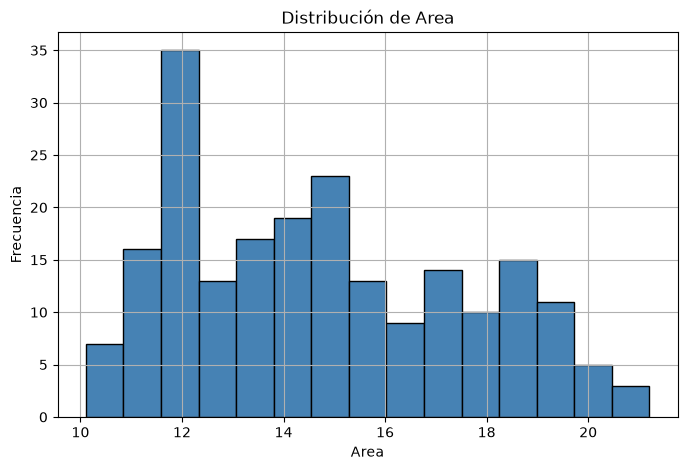

In [69]:
plt.figure(figsize=(8, 5))
plt.hist(df["Area"], bins=15, color="steelblue", edgecolor="black")
plt.title("Distribución de Area")
plt.xlabel("Area")
plt.ylabel("Frecuencia")
plt.grid()
plt.show()

Dispersión de Area vs Perimeter por variedad

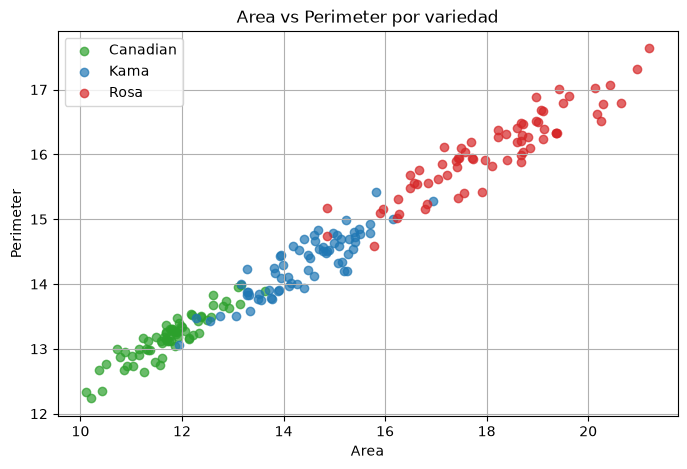

In [70]:
plt.figure(figsize=(8, 5))

colores = {"Kama": "tab:blue", "Rosa": "tab:red", "Canadian": "tab:green"}
for variedad, grupo in df.groupby("Class"):
    plt.scatter(grupo["Area"], grupo["Perimeter"],
                label=variedad, color=colores[variedad], alpha=0.7)

plt.title("Area vs Perimeter por variedad")
plt.xlabel("Area")
plt.ylabel("Perimeter")
plt.legend()
plt.grid()
plt.show()

**Modelos de clasificación: K-Vecinos vs Árbol de Decisión**

Se entrenan ambos modelos con los datos de entrenamiento y se evalúan con Accuracy y classification_report sobre el conjunto de prueba.

K-Vecinos

In [71]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

acc_knn = accuracy_score(y_test, y_pred_knn)
print("K-Vecinos | Accuracy:", round(acc_knn, 4))
print(classification_report(y_test, y_pred_knn))

K-Vecinos | Accuracy: 0.9524
              precision    recall  f1-score   support

    Canadian       0.95      1.00      0.98        21
        Kama       0.91      0.95      0.93        21
        Rosa       1.00      0.90      0.95        21

    accuracy                           0.95        63
   macro avg       0.95      0.95      0.95        63
weighted avg       0.95      0.95      0.95        63



Árbol de Decisión

In [72]:
arbol = DecisionTreeClassifier(random_state=42)
arbol.fit(X_train, y_train)
y_pred_arbol = arbol.predict(X_test)

acc_arbol = accuracy_score(y_test, y_pred_arbol)
print("Árbol de Decisión | Accuracy:", round(acc_arbol, 4))
print(classification_report(y_test, y_pred_arbol))

Árbol de Decisión | Accuracy: 0.8889
              precision    recall  f1-score   support

    Canadian       0.90      0.86      0.88        21
        Kama       0.83      0.90      0.86        21
        Rosa       0.95      0.90      0.93        21

    accuracy                           0.89        63
   macro avg       0.89      0.89      0.89        63
weighted avg       0.89      0.89      0.89        63



Comparación

In [73]:
print("Comparación de Accuracy")
print("K-Vecinos:        ", round(acc_knn, 4))
print("Árbol de Decisión:", round(acc_arbol, 4))

Comparación de Accuracy
K-Vecinos:         0.9524
Árbol de Decisión: 0.8889


**Resultados y conclusiones**

Tabla resumen de resultados

In [74]:
resumen = pd.DataFrame({
    "Modelo": ["K-Vecinos (k=5)", "Árbol de Decisión"],
    "Accuracy": [round(acc_knn, 4), round(acc_arbol, 4)]
})
resumen

,Modelo,Accuracy
0,K-Vecinos (k=5),0.9524
1,Árbol de Decisión,0.8889


Gráfico de comparación

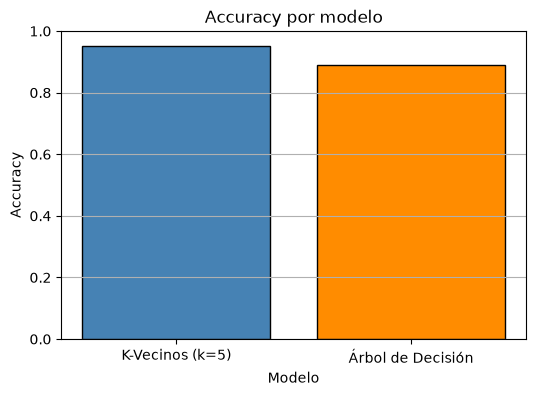

In [75]:
plt.figure(figsize=(6, 4))
plt.bar(resumen["Modelo"], resumen["Accuracy"], color=["steelblue", "darkorange"], edgecolor="black")
plt.title("Accuracy por modelo")
plt.xlabel("Modelo")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()

**Conclusiones**

1. **Datos:** el dataset tiene 210 filas, 7 características numéricas y 3 variedades balanceadas (70 cada una), sin nulos ni duplicados.
2. **Álgebra lineal:** con NumPy se calcularon producto punto, normas y la similitud coseno entre Area y Perimeter (0.9986), que indica que ambas crecen casi en la misma dirección. También se resolvió un sistema de ecuaciones con `np.linalg.solve`.
3. **Estadística:** Area tiene media 14.757 y desviación estándar 2.822 (ddof=1). La implementación manual de varianza y desviación coincide con NumPy.
4. **Atípicos:** con el criterio de 2σ se detectaron 4 valores atípicos en Area, todos de la variedad Rosa. Se conservan porque corresponden a granos grandes propios de esa variedad.
5. **Gráficos:** la dispersión de Area vs Perimeter muestra las tres variedades bastante separadas, lo que facilita la clasificación.
6. **Modelos:** K-Vecinos obtuvo un Accuracy de 0.9524 y el Árbol de Decisión de 0.8889 sobre 63 muestras de prueba. K-Vecinos rindió mejor en este conjunto.
7. **Limitaciones:** el dataset es sintético, así que el Accuracy demuestra la metodología y no estima el rendimiento real. Además, el escalado se aplicó antes de separar los datos, siguiendo el enunciado; en un proyecto real se ajustaría solo con el entrenamiento.